# 5 — Visualización orientada a preguntas

Un gráfico no es el objetivo: es evidencia para responder una pregunta. En cada ejercicio primero escribí qué querés averiguar, luego construí la agregación y finalmente redactá una conclusión de dos o tres oraciones.

Este notebook se ejecuta manualmente **después** de que el Job termina correctamente; no forma parte del pipeline.

In [0]:
dbutils.widgets.text("student_id", "martin_lin", "01 - Identificador")
dbutils.widgets.dropdown("scale", "small", ["test", "small", "demo"], "02 - Escala")

In [0]:
%run ../common/config

In [0]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

catalog = spark.sql("SELECT current_catalog()").first()[0]
config = CourseConfig(catalog, dbutils.widgets.get("student_id"), dbutils.widgets.get("scale"))
daily = qualified_table(config, "gold_daily_sales")
risk = qualified_table(config, "gold_customer_risk")
batch = qualified_table(config, "gold_batch_summary")
for table in [daily, risk, batch]:
    assert spark.catalog.tableExists(table), f"Falta {table}. Ejecutá primero el Job completo."

## Ejemplo resuelto

**Pregunta:** ¿Qué categoría concentra el mayor monto vendido?

La agregación se hace con Spark. Sólo el resultado pequeño se convierte a Pandas para dibujarlo. Un gráfico de barras ordenado permite comparar categorías; un gráfico de torta haría más difícil comparar valores cercanos.

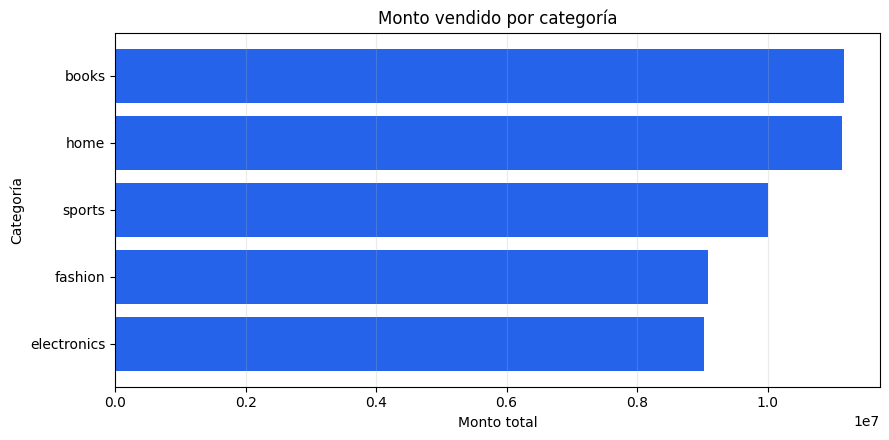

Respuesta: books es la categoría con mayor monto vendido (11,165,281.86).


In [0]:
category_sales = (spark.table(daily)
    .groupBy("category")
    .agg(F.sum("total_amount").alias("total_amount"))
    .orderBy(F.desc("total_amount")))

plot_data = category_sales.toPandas().sort_values("total_amount")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(plot_data["category"], plot_data["total_amount"], color="#2563eb")
ax.set_title("Monto vendido por categoría")
ax.set_xlabel("Monto total")
ax.set_ylabel("Categoría")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()

leader = category_sales.first()
print(f"Respuesta: {leader.category} es la categoría con mayor monto vendido ({leader.total_amount:,.2f}).")

## Consigna 1 — Evolución temporal

**Pregunta:** ¿Qué día tuvo el mayor monto vendido y ese día también fue el de mayor cantidad de transacciones?

Construí una visualización temporal que permita comparar ambas métricas sin ocultar sus unidades. Explicá si los dos máximos coinciden y qué implica que coincidan —o no— sobre el ticket promedio. Fuente sugerida: `gold_daily_sales`.

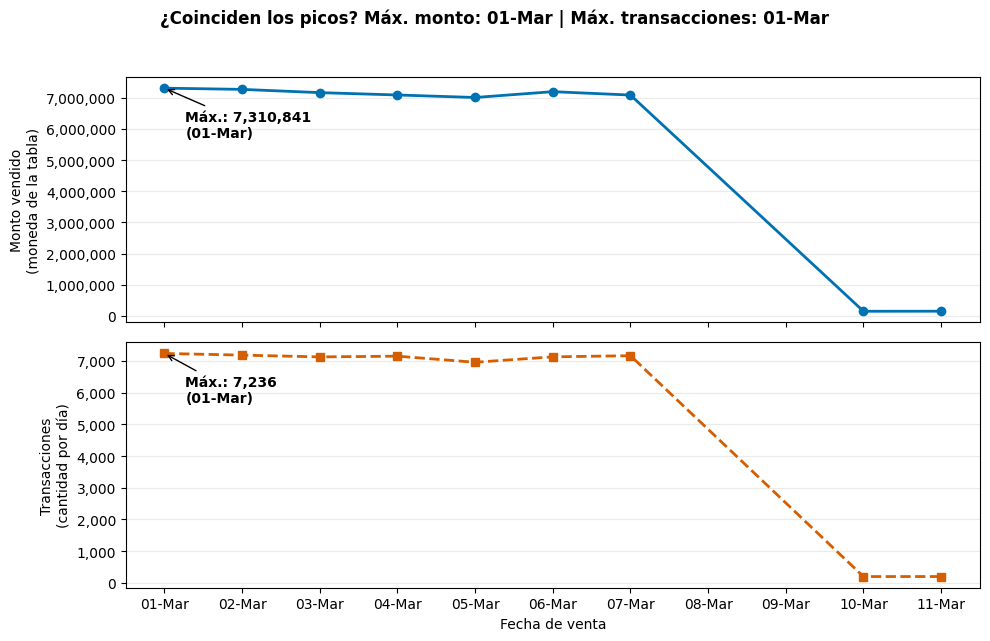

Mayor monto: 2026-03-01 (7,310,840.77)
Mayor cantidad de transacciones: 2026-03-01 (7,236)
¿Coinciden?: Sí
Ticket global: 1,001.63 | día de máx. monto: 1,010.34 | día de máx. transacciones: 1,010.34


sale_date,total_amount,transaction_count,avg_ticket
2026-03-01T00:00:00.000Z,7310840.77,7236.0,1010.342837202875
2026-03-02T00:00:00.000Z,7271589.97,7183.0,1012.33328275094
2026-03-03T00:00:00.000Z,7167008.24,7127.0,1005.613615827136
2026-03-04T00:00:00.000Z,7091526.73,7150.0,991.82192027972
2026-03-05T00:00:00.000Z,7010989.71,6958.0,1007.615652486347
2026-03-06T00:00:00.000Z,7198310.64,7129.0,1009.722350960864
2026-03-07T00:00:00.000Z,7089104.28,7165.0,989.407436147941
2026-03-10T00:00:00.000Z,144813.0,200.0,724.065
2026-03-11T00:00:00.000Z,147014.99,201.0,731.417860696517


In [0]:
import pandas as pd
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# 1) Transformación: agregación diaria en Spark
daily_agg = (spark.table(daily)
    .groupBy("sale_date")
    .agg(F.sum("total_amount").alias("total_amount"),
         F.sum("transaction_count").alias("transaction_count"))
    .withColumn("avg_ticket", F.col("total_amount") / F.col("transaction_count"))
    .orderBy("sale_date"))

plot_data = daily_agg.toPandas()
plot_data["sale_date"] = pd.to_datetime(plot_data["sale_date"])
for c in ["total_amount", "transaction_count", "avg_ticket"]:
    plot_data[c] = plot_data[c].astype(float)

top_amount = plot_data.loc[plot_data["total_amount"].idxmax()]
top_trx = plot_data.loc[plot_data["transaction_count"].idxmax()]
global_ticket = plot_data["total_amount"].sum() / plot_data["transaction_count"].sum()

# 2) Gráfico: un panel por métrica, con distinto marcador y estilo de línea además del color
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)

ax1.plot(plot_data["sale_date"], plot_data["total_amount"],
         color="#0072B2", marker="o", linestyle="-", linewidth=2)
ax1.annotate(f"Máx.: {top_amount['total_amount']:,.0f}\n({top_amount['sale_date']:%d-%b})",
             (top_amount["sale_date"], top_amount["total_amount"]),
             textcoords="offset points", xytext=(15, -35),
             arrowprops=dict(arrowstyle="->"), fontweight="bold")
ax1.set_ylabel("Monto vendido\n(moneda de la tabla)")
ax1.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax1.grid(axis="y", alpha=0.25)

ax2.plot(plot_data["sale_date"], plot_data["transaction_count"],
         color="#D55E00", marker="s", linestyle="--", linewidth=2)
ax2.annotate(f"Máx.: {int(top_trx['transaction_count']):,}\n({top_trx['sale_date']:%d-%b})",
             (top_trx["sale_date"], top_trx["transaction_count"]),
             textcoords="offset points", xytext=(15, -35),
             arrowprops=dict(arrowstyle="->"), fontweight="bold")
ax2.set_ylabel("Transacciones\n(cantidad por día)")
ax2.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax2.set_xlabel("Fecha de venta")
ax2.xaxis.set_major_locator(mdates.DayLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
ax2.grid(axis="y", alpha=0.25)

fig.suptitle(f"¿Coinciden los picos? Máx. monto: {top_amount['sale_date']:%d-%b} | "
             f"Máx. transacciones: {top_trx['sale_date']:%d-%b}", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 3) Números para la conclusión
coinciden = top_amount["sale_date"] == top_trx["sale_date"]
print(f"Mayor monto: {top_amount['sale_date']:%Y-%m-%d} ({top_amount['total_amount']:,.2f})")
print(f"Mayor cantidad de transacciones: {top_trx['sale_date']:%Y-%m-%d} ({int(top_trx['transaction_count']):,})")
print(f"¿Coinciden?: {'Sí' if coinciden else 'No'}")
print(f"Ticket global: {global_ticket:,.2f} | día de máx. monto: {top_amount['avg_ticket']:,.2f} "
      f"| día de máx. transacciones: {top_trx['avg_ticket']:,.2f}")
display(plot_data)

**Conclusión:** El mayor monto se vendió el 2026-03-01 (7,310,840.77) y la mayor cantidad de transacciones fue el 2026-03-01 (7236), por lo que sí coinciden. El ticket promedio ese día fue 1,010.34 frente a 1,001.63 global, lo que indica que el pico se debió a un mayor volumen de transacción.

## Consigna 2 — Canal y fraude

**Pregunta:** ¿Qué canal de pago presenta la mayor tasa de fraude? ¿La conclusión se sostiene al considerar el número de transacciones de cada canal?

Mostrá tasa y volumen de manera legible. No compares sólo cantidades de fraude: calculá el denominador correcto. Fuente sugerida: `gold_daily_sales`.

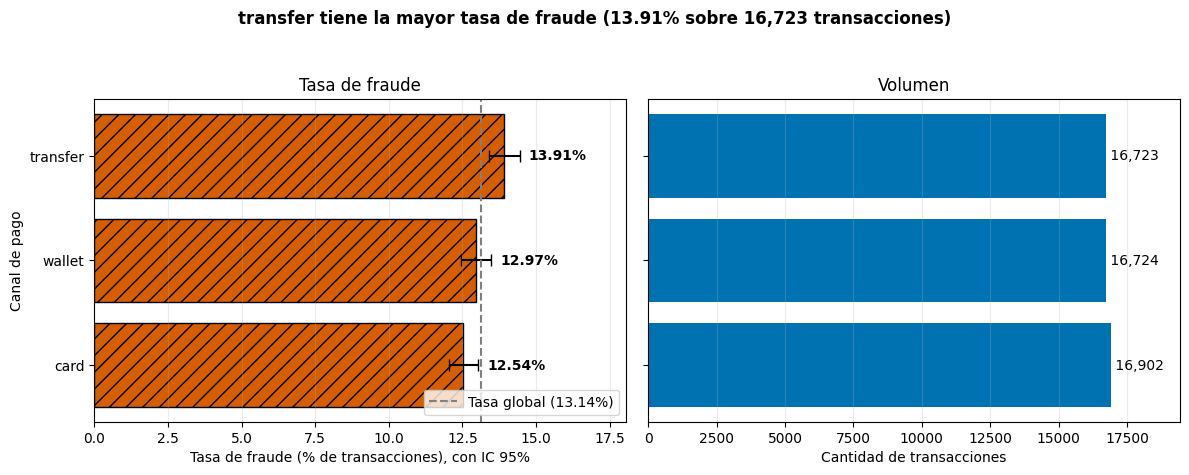

Tasa global: 13.14%


payment_channel,fraud_transactions,transaction_count,fraud_rate,ci_low,ci_high
transfer,2327.0,16723.0,0.1391496741015368,0.13398679175243625,0.14447830712193824
wallet,2169.0,16724.0,0.1296938531451806,0.12468684794967569,0.1348709422197387
card,2119.0,16902.0,0.12536977872441132,0.12046250651538437,0.1304473091781449


In [0]:
import numpy as np

# 1) Transformación: tasa con el denominador correcto
channel_fraud = (spark.table(daily)
    .groupBy("payment_channel")
    .agg(F.sum("fraud_transactions").alias("fraud_transactions"),
         F.sum("transaction_count").alias("transaction_count"))
    .withColumn("fraud_rate", F.col("fraud_transactions") / F.col("transaction_count"))
    .orderBy(F.desc("fraud_rate")))

plot_data = channel_fraud.toPandas()
for c in ["fraud_transactions", "transaction_count", "fraud_rate"]:
    plot_data[c] = plot_data[c].astype(float)
plot_data = plot_data.sort_values("fraud_rate").reset_index(drop=True)  # el mayor queda arriba en barh

def wilson(k, n, z=1.96):
    p = k / n
    denom = 1 + z**2 / n
    centro = (p + z**2 / (2 * n)) / denom
    mitad = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return centro - mitad, centro + mitad

ci = plot_data.apply(lambda r: wilson(r["fraud_transactions"], r["transaction_count"]), axis=1)
plot_data["ci_low"] = [c[0] for c in ci]
plot_data["ci_high"] = [c[1] for c in ci]

global_rate = plot_data["fraud_transactions"].sum() / plot_data["transaction_count"].sum()
top = plot_data.iloc[-1]

# 2) Gráfico: tasa y volumen, ambos con etiquetas numéricas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
y = np.arange(len(plot_data))

rate = plot_data["fraud_rate"].values * 100
xerr = np.array([rate - plot_data["ci_low"].values * 100,
                 plot_data["ci_high"].values * 100 - rate])
ax1.barh(y, rate, xerr=xerr, capsize=4, color="#D55E00", hatch="//", edgecolor="black")
for i, v in enumerate(rate):
    ax1.text(plot_data["ci_high"][i] * 100 + 0.3, i, f"{v:.2f}%", va="center", fontweight="bold")
ax1.axvline(global_rate * 100, color="gray", linestyle="--", label=f"Tasa global ({global_rate:.2%})")
ax1.set_yticks(y)
ax1.set_yticklabels(plot_data["payment_channel"])
ax1.set_xlim(0, plot_data["ci_high"].max() * 100 * 1.25)
ax1.set_xlabel("Tasa de fraude (% de transacciones), con IC 95%")
ax1.set_ylabel("Canal de pago")
ax1.set_title("Tasa de fraude")
ax1.legend(loc="lower right")
ax1.grid(axis="x", alpha=0.25)

vol = plot_data["transaction_count"].values
ax2.barh(y, vol, color="#0072B2")
for i, v in enumerate(vol):
    ax2.text(v, i, f" {v:,.0f}", va="center")
ax2.set_xlim(0, vol.max() * 1.15)
ax2.set_xlabel("Cantidad de transacciones")
ax2.set_title("Volumen")
ax2.grid(axis="x", alpha=0.25)

fig.suptitle(f"{top['payment_channel']} tiene la mayor tasa de fraude "
             f"({top['fraud_rate']:.2%} sobre {int(top['transaction_count']):,} transacciones)",
             fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

# 3) Números para la conclusión
print(f"Tasa global: {global_rate:.2%}")
display(plot_data.sort_values("fraud_rate", ascending=False))

**Conclusión:** El canal con mayor tasa de fraude es transfer (13,91%), frente a una tasa global de 13,14%. Procesó 16.723 transacciones, un volumen similar al de wallet (16.724) y card (16.902), por lo que la diferencia no se explica por tener pocos datos. Su intervalo de confianza (13,40% a 14,45%) no se superpone con el de card (12,05% a 13,04%), pero sí con el de wallet (12,47% a 13,49%), así que transfer supera claramente a card y solo marginalmente a wallet.


## Consigna 3 — Concentración geográfica y de producto

**Pregunta:** ¿Qué combinación de país y categoría genera el mayor monto? ¿Existe una categoría dominante en todos los países o cambia según el mercado?

Elegí una visualización que permita comparar simultáneamente países y categorías. Justificá brevemente por qué ese tipo de gráfico es adecuado. Fuente sugerida: `gold_daily_sales`.

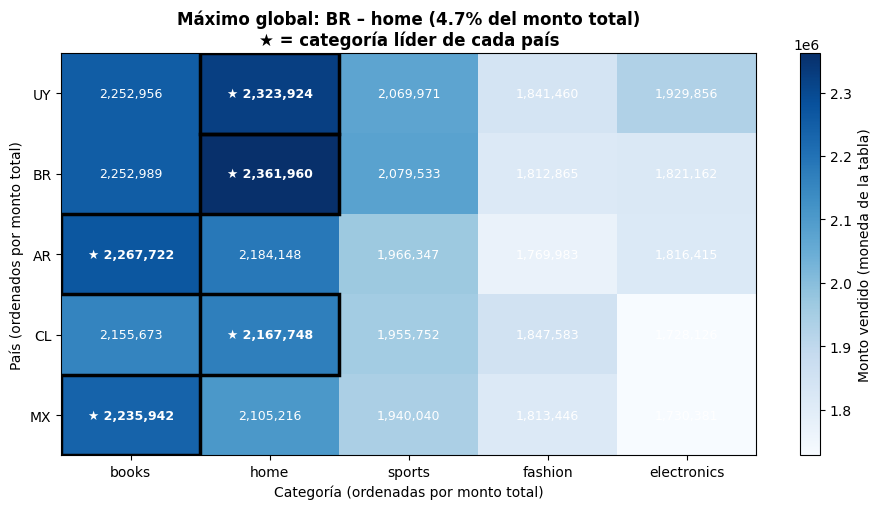

Máximo global: BR - home (2,361,959.97, 4.7% del total)

Categoría líder por país:
  UY: home (2,323,924) | 2da: books (2,252,956) | ventaja 3.2%
  BR: home (2,361,960) | 2da: books (2,252,989) | ventaja 4.8%
  AR: books (2,267,722) | 2da: home (2,184,148) | ventaja 3.8%
  CL: home (2,167,748) | 2da: books (2,155,673) | ventaja 0.6%
  MX: books (2,235,942) | 2da: home (2,105,216) | ventaja 6.2%


country,books,home,sports,fashion,electronics
UY,2252955.97,2323924.46,2069971.18,1841459.93,1929855.99
BR,2252988.52,2361959.97,2079532.92,1812864.61,1821162.44
AR,2267722.26,2184148.34,1966346.81,1769983.03,1816414.85
CL,2155673.48,2167748.03,1955752.03,1847582.51,1728126.43
MX,2235941.63,2105216.34,1940040.26,1813445.8,1730380.54


In [0]:
import numpy as np

# 1) Transformación
country_cat = (spark.table(daily)
    .groupBy("country", "category")
    .agg(F.sum("total_amount").alias("total_amount")))

long_data = country_cat.toPandas()
long_data["total_amount"] = long_data["total_amount"].astype(float)

matrix = long_data.pivot(index="country", columns="category", values="total_amount").fillna(0)
matrix = matrix.loc[matrix.sum(axis=1).sort_values(ascending=False).index,   # países de mayor a menor
                    matrix.sum(axis=0).sort_values(ascending=False).index]   # categorías de mayor a menor

best = long_data.sort_values("total_amount", ascending=False).iloc[0]
total_global = long_data["total_amount"].sum()

# 2) Gráfico: color (intensidad) + número en cada celda + estrella en el líder de cada país
fig, ax = plt.subplots(figsize=(9.5, 5.2))
im = ax.imshow(matrix.values, cmap="Blues", aspect="auto")

ax.set_xticks(range(len(matrix.columns)))
ax.set_xticklabels(matrix.columns)
ax.set_yticks(range(len(matrix.index)))
ax.set_yticklabels(matrix.index)

umbral = matrix.values.max() * 0.6
lider = {pais: int(np.argmax(matrix.loc[pais].values)) for pais in matrix.index}
for i, pais in enumerate(matrix.index):
    for j in range(matrix.shape[1]):
        v = matrix.values[i, j]
        es_lider = lider[pais] == j
        ax.text(j, i, f"{'★ ' if es_lider else ''}{v:,.0f}", ha="center", va="center", fontsize=9,
                color="white" if v > umbral else "black",
                fontweight="bold" if es_lider else "normal")
        if es_lider:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                       edgecolor="black", linewidth=2.5))

ax.set_title(f"Máximo global: {best['country']} – {best['category']} "
             f"({best['total_amount'] / total_global:.1%} del monto total)\n"
             f"★ = categoría líder de cada país", fontweight="bold")
ax.set_xlabel("Categoría (ordenadas por monto total)")
ax.set_ylabel("País (ordenados por monto total)")
fig.colorbar(im, ax=ax, label="Monto vendido (moneda de la tabla)")
fig.tight_layout()
plt.show()

# 3) Números para la conclusión
print(f"Máximo global: {best['country']} - {best['category']} ({best['total_amount']:,.2f}, "
      f"{best['total_amount'] / total_global:.1%} del total)")
print("\nCategoría líder por país:")
for pais in matrix.index:
    s = matrix.loc[pais].sort_values(ascending=False)
    print(f"  {pais}: {s.index[0]} ({s.iloc[0]:,.0f}) | 2da: {s.index[1]} ({s.iloc[1]:,.0f}) "
          f"| ventaja {s.iloc[0] / s.iloc[1] - 1:.1%}")
display(matrix.reset_index())

**Conclusión:** La combinación con mayor monto es BR–home (2.361.960, 4,7% del monto total). No existe una categoría dominante en todos los mercados: home lidera en UY, BR y CL, mientras que books lidera en AR y MX. Las diferencias entre las dos primeras categorías son chicas (0,6% en CL a 6,2% en MX), por lo que el liderazgo de cada país es sensible y home y books están prácticamente parejas en todos los mercados.

## Consigna 4 — Calidad del pipeline

**Pregunta:** ¿Qué proporción de cada lote fue aceptada y rechazada? ¿El lote nuevo presenta una calidad diferente del lote inicial?

Compará lotes usando proporciones además de cantidades absolutas. Señalá cualquier limitación de comparar lotes de tamaños distintos. Fuente sugerida: `gold_batch_summary`.

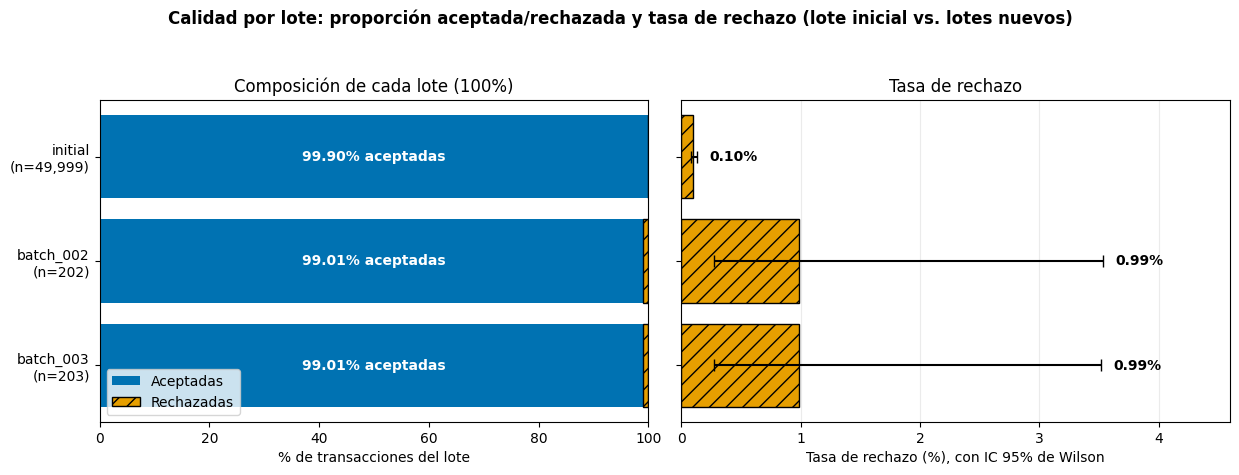

initial: rechazo 0.102% [IC95% 0.078% - 0.134%] (51 sobre 49,999)
batch_002: rechazo 0.990% [IC95% 0.272% - 3.538%] (2 sobre 202) = 9.7x el lote inicial
batch_003: rechazo 0.985% [IC95% 0.271% - 3.521%] (2 sobre 203) = 9.7x el lote inicial


source_batch_id,accepted,rejected,total,accepted_pct,rejected_pct,ci_low,ci_high
initial,49948.0,51.0,49999.0,0.998979979599592,0.0010200204004080081,7.759458200657637E-4,0.0013407658829747292
batch_002,200.0,2.0,202.0,0.9900990099009901,0.009900990099009901,0.002719364275706272,0.035375947847790634
batch_003,201.0,2.0,203.0,0.9901477832512315,0.009852216748768473,0.0027059476770762148,0.03520518818727602


In [0]:
import numpy as np

# 1) Transformación
batch_quality = (spark.table(batch)
    .select("source_batch_id",
            F.col("accepted_transactions").alias("accepted"),
            F.col("rejected_transactions").alias("rejected"))
    .withColumn("total", F.col("accepted") + F.col("rejected"))
    .withColumn("accepted_pct", F.col("accepted") / F.col("total"))
    .withColumn("rejected_pct", F.col("rejected") / F.col("total")))

plot_data = batch_quality.toPandas()
for c in ["accepted", "rejected", "total", "accepted_pct", "rejected_pct"]:
    plot_data[c] = plot_data[c].astype(float)

# Orden: lote inicial primero, luego los nuevos por nombre
orden = ["initial"] + sorted(b for b in plot_data["source_batch_id"] if b != "initial")
plot_data = plot_data.set_index("source_batch_id").loc[orden].reset_index()

def wilson(k, n, z=1.96):
    p = k / n
    denom = 1 + z**2 / n
    centro = (p + z**2 / (2 * n)) / denom
    mitad = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return centro - mitad, centro + mitad

ci = plot_data.apply(lambda r: wilson(r["rejected"], r["total"]), axis=1)
plot_data["ci_low"] = [c[0] for c in ci]
plot_data["ci_high"] = [c[1] for c in ci]

# 2) Gráfico
labels = [f"{b}\n(n={int(n):,})" for b, n in zip(plot_data["source_batch_id"], plot_data["total"])]
y = np.arange(len(plot_data))
acc = plot_data["accepted_pct"].values * 100
rej = plot_data["rejected_pct"].values * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.8), sharey=True)

# Panel 1: composición al 100% (azul liso = aceptadas, naranja rayado = rechazadas)
ax1.barh(y, acc, color="#0072B2", label="Aceptadas")
ax1.barh(y, rej, left=acc, color="#E69F00", hatch="//", edgecolor="black", label="Rechazadas")
for i in range(len(y)):
    ax1.text(50, i, f"{acc[i]:.2f}% aceptadas", ha="center", va="center",
             color="white", fontweight="bold")
ax1.set_yticks(y)
ax1.set_yticklabels(labels)
ax1.set_xlim(0, 100)
ax1.set_xlabel("% de transacciones del lote")
ax1.set_title("Composición de cada lote (100%)")
ax1.legend(loc="lower left")
ax1.invert_yaxis()

# Panel 2: tasa de rechazo con IC 95%
xerr = np.array([rej - plot_data["ci_low"].values * 100,
                 plot_data["ci_high"].values * 100 - rej])
ax2.barh(y, rej, xerr=xerr, capsize=4, color="#E69F00", hatch="//", edgecolor="black")
for i, v in enumerate(rej):
    ax2.text(plot_data["ci_high"][i] * 100 + 0.1, i, f"{v:.2f}%", va="center", fontweight="bold")
ax2.set_xlim(0, plot_data["ci_high"].max() * 100 * 1.3)
ax2.set_xlabel("Tasa de rechazo (%), con IC 95% de Wilson")
ax2.set_title("Tasa de rechazo")
ax2.grid(axis="x", alpha=0.25)

fig.suptitle("Calidad por lote: proporción aceptada/rechazada y tasa de rechazo "
             "(lote inicial vs. lotes nuevos)", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

# 3) Números para la conclusión
base = plot_data.iloc[0]
print(f"{base['source_batch_id']}: rechazo {base['rejected_pct']:.3%} "
      f"[IC95% {base['ci_low']:.3%} - {base['ci_high']:.3%}] "
      f"({int(base['rejected'])} sobre {int(base['total']):,})")
for _, r in plot_data.iloc[1:].iterrows():
    print(f"{r['source_batch_id']}: rechazo {r['rejected_pct']:.3%} "
          f"[IC95% {r['ci_low']:.3%} - {r['ci_high']:.3%}] "
          f"({int(r['rejected'])} sobre {int(r['total']):,}) "
          f"= {r['rejected_pct'] / base['rejected_pct']:.1f}x el lote inicial")
display(plot_data[["source_batch_id", "accepted", "rejected", "total",
                   "accepted_pct", "rejected_pct", "ci_low", "ci_high"]])

**Conclusión:** El lote inicial aceptó 99,90% de sus 49.999 transacciones (rechazo 0,102%), mientras que batch_002 y batch_003 rechazaron cerca de 0,99% (2 de 202 y 2 de 203), unas 9,7 veces más. Los intervalos de confianza no se superponen (el máximo del inicial es 0,134% y el mínimo de los nuevos es 0,27%), lo que sugiere que los lotes nuevos tienen una calidad distinta. Aun así, la estimación es frágil: los lotes nuevos son ~250 veces más chicos y se basan en solo 2 rechazos cada uno, con intervalos que llegan hasta ~3,5%, así que conviene confirmarlo con más lotes.

## Criterios de entrega

Para cada consigna entregá: (1) la transformación de datos, (2) un gráfico, y (3) una conclusión de dos o tres oraciones que responda explícitamente la pregunta.

Cada gráfico debe tener título informativo, ejes y unidades legibles, categorías ordenadas cuando corresponda y una elección de color que no sea la única forma de comunicar el significado. No conviertas una tabla Silver completa a Pandas: agregá primero con Spark y convertí sólo el resultado pequeño.